

Importar as bibliotecas e gerar o DataFrame sintético da atividade:




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

Conferir se os dados foram criados:

In [2]:
df_sistema.head()

,idade,plano,tempo_uso_horas,bugs_reportados,satisfacao
0,62,Gratuito,14.165127,3,1
1,41,Básico,19.076874,1,2
2,44,Básico,28.574818,3,6
3,40,Gratuito,28.898728,3,6
4,41,Básico,6.566953,1,2


Countplot conta quantos usuários existem em cada categoria. Vamos ordenar as barras pela frequência, da maior para a menor.

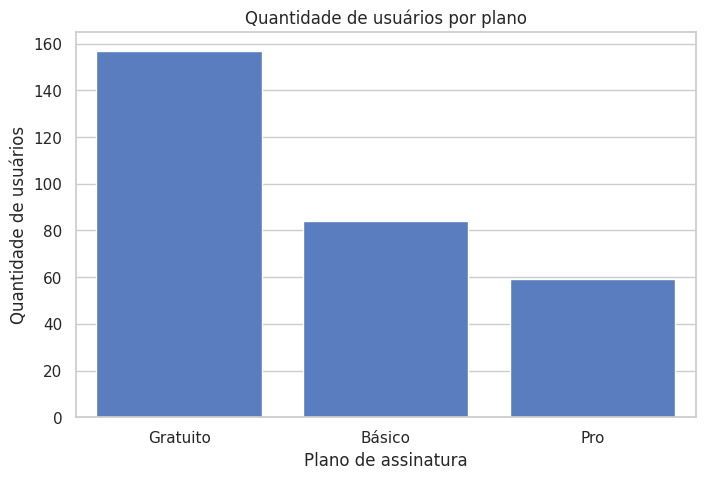

In [3]:
plt.figure(figsize=(8, 5))

ordem_planos = df_sistema['plano'].value_counts().index

sns.countplot(
    data=df_sistema,
    x='plano',
    order=ordem_planos
)

plt.title('Quantidade de usuários por plano')
plt.xlabel('Plano de assinatura')
plt.ylabel('Quantidade de usuários')
plt.show()

Histograma da idade com KDE

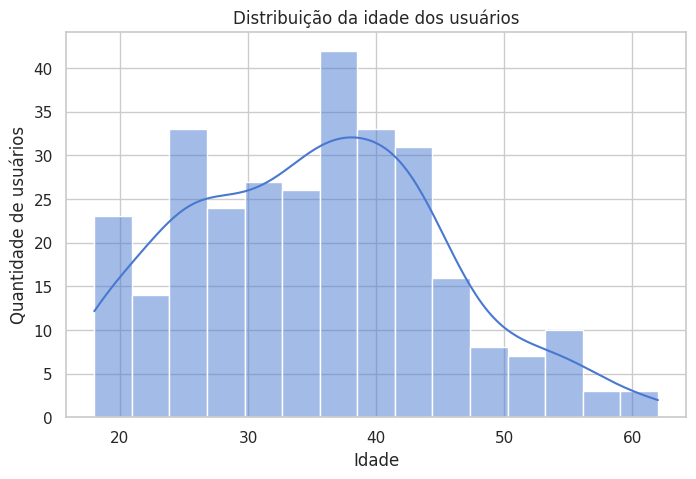

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_sistema,
    x='idade',
    bins=15,
    kde=True
)

plt.title('Distribuição da idade dos usuários')
plt.xlabel('Idade')
plt.ylabel('Quantidade de usuários')
plt.show()

O boxplot permite comparar a mediana, a dispersão e os valores extremos do tempo de uso em cada plano.

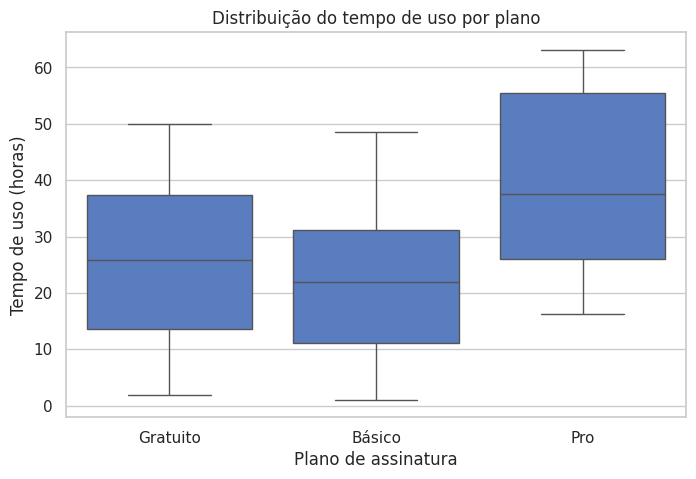

In [5]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_sistema,
    x='plano',
    y='tempo_uso_horas',
    order=['Gratuito', 'Básico', 'Pro']
)

plt.title('Distribuição do tempo de uso por plano')
plt.xlabel('Plano de assinatura')
plt.ylabel('Tempo de uso (horas)')
plt.show()

O violinplot mostra a distribuição das notas de satisfação, incluindo regiões em que há maior concentração de usuários.

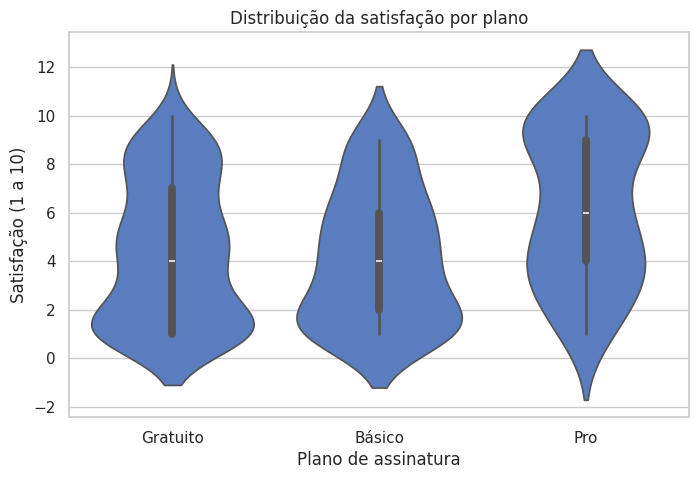

In [6]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df_sistema,
    x='plano',
    y='satisfacao',
    order=['Gratuito', 'Básico', 'Pro']
)

plt.title('Distribuição da satisfação por plano')
plt.xlabel('Plano de assinatura')
plt.ylabel('Satisfação (1 a 10)')
plt.show()

O eixo X é o tempo de uso, o eixo Y é a satisfação, as cores representam os planos e o tamanho dos pontos representa a quantidade de bugs reportados.

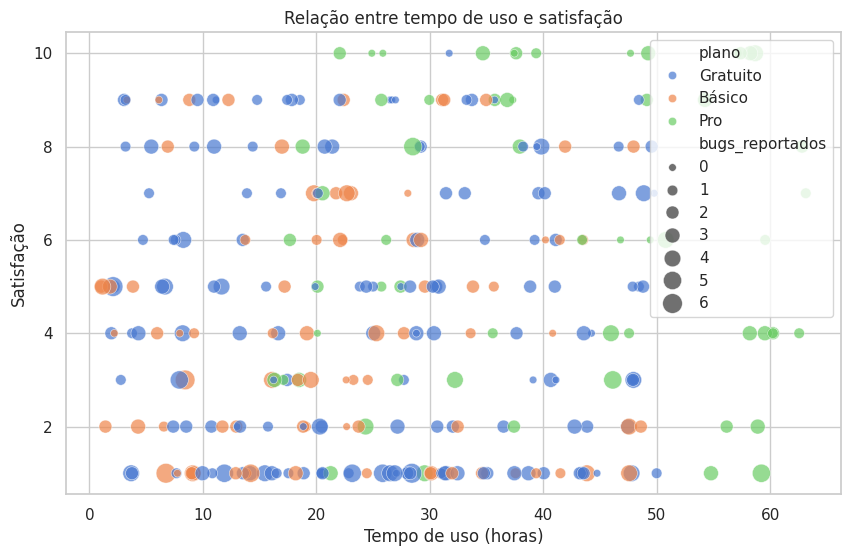

In [7]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    size='bugs_reportados',
    sizes=(30, 200),
    alpha=0.7
)

plt.title('Relação entre tempo de uso e satisfação')
plt.xlabel('Tempo de uso (horas)')
plt.ylabel('Satisfação')
plt.show()

Selecionar apenas as colunas numéricas e calcular a correlação de Pearson entre elas.

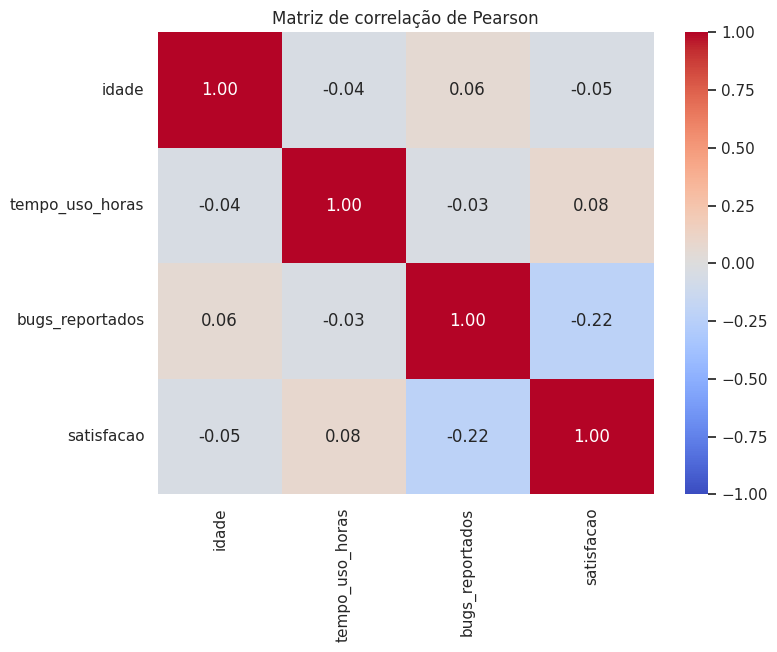

In [8]:
correlacao = df_sistema.select_dtypes(
    include='number'
).corr(method='pearson')

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.title('Matriz de correlação de Pearson')
plt.show()

O pairplot cria gráficos de dispersão entre todas as combinações das três variáveis, além dos histogramas ou densidades na diagonal.

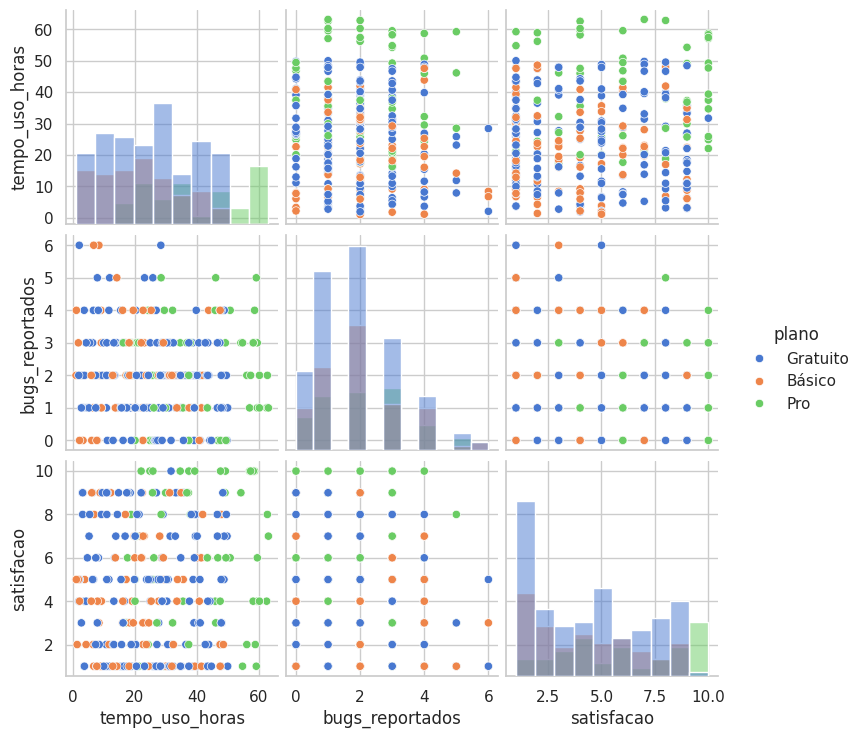

In [9]:
sns.pairplot(
    df_sistema,
    vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'],
    hue='plano',
    diag_kind='hist'
)

plt.show()